In [5]:
import numpy as np
from Illustrator_arnav import Illustrator
from Simulator_Yuming import Simulator2

def make_simple_baseline():
# a random system which is simple and stable, with input noise and observation noise,  as for reference
    A = np.array([[0.85, 0.00],
                  [0.00, 0.55]])

    B = np.array([[1.00],
                  [0.40]])

    C = np.eye(2)

    return Simulator2({"A": A, "B": B, "C": C,
                      "Q": 0.002*np.eye(2),
                      "R": 0.002*np.eye(2),
                      "x0": np.zeros(2),
                      "seed": 0})

sim_base = make_simple_baseline()
T = 80

U = sim_base.generate_input(
    T,
    pattern="pulse",
    amplitude=2.0,
    pulse_time=10,
    pulse_width=5
)

result = sim_base.simulate(
    T,
    U=U,
    process_noise=True,
    observation_noise=True
)
obs = result['Y']
data = obs[np.newaxis, :, :]
print(data.shape)

(1, 80, 2)


In [6]:
ill = Illustrator(data)
print(ill.trial_cnt)
print(ill.neuron_cnt)
print(ill.timestep_cnt)


1
2
80


In [7]:
print('Test get_trial_average')
print('No specification')
res = ill.get_trial_average()
print(ill.get_trial_average())
print(res.shape)


Test get_trial_average
No specification
[[ 5.62282642e-03 -5.90790909e-03]
 [ 4.68470898e-03  2.08622983e-02]
 [ 5.11891442e-02 -1.16564186e-02]
 [-6.15902489e-02  1.67777158e-02]
 [-4.40287880e-02 -3.22840576e-02]
 [-4.07503609e-03  9.77564429e-02]
 [ 1.20782321e-02  4.00798523e-02]
 [-7.77976738e-02 -1.16418647e-02]
 [-1.01000676e-01  3.01362428e-03]
 [-9.94381864e-02 -1.54929629e-03]
 [-8.09150432e-02  1.36828962e-01]
 [ 2.05109946e+00  8.58920581e-01]
 [ 3.87915798e+00  1.42660644e+00]
 [ 5.24458180e+00  1.52760707e+00]
 [ 6.41967066e+00  1.67283511e+00]
 [ 7.36790624e+00  1.62103155e+00]
 [ 6.37180945e+00  8.86599159e-01]
 [ 5.50267231e+00  4.54493962e-01]
 [ 4.70042106e+00  3.07112589e-01]
 [ 4.00909255e+00  1.66875666e-01]
 [ 3.44350006e+00  1.30014846e-01]
 [ 2.84578409e+00  6.64780016e-02]
 [ 2.45972866e+00  1.54490441e-01]
 [ 2.08724717e+00  8.09410583e-02]
 [ 1.80898296e+00  8.25504183e-02]
 [ 1.49401452e+00  4.13882578e-02]
 [ 1.28249994e+00 -1.06888195e-01]
 [ 9.24419113e-

In [8]:
print('Get neuron statistics')
res = ill.get_neuron_statistics()

Get neuron statistics
Neuron statistics
-----------------
Neuron  0: mean=0.768, std=1.753, energy= 3.662, var=3.073, peak=7.368, peak_time= 15.000, peak_slope=1.619
Neuron  1: mean=0.122, std=0.368, energy= 0.150, var=0.135, peak=1.673, peak_time= 14.000, peak_slope=0.435


In [10]:
print('get_psd')

res1 = ill.get_PSD()
res2 = ill.get_PSD([0,1], average_across_trials=True)
res3 = ill.get_PSD([0,1],[i for i in range(1,30)] ,average_across_trials=True)
print(res1)
print(res2)
print(res3)

get_psd
{np.int64(0): (array([0. , 0.1, 0.2, 0.3, 0.4, 0.5]), array([1.04531133, 3.55464685, 0.74746478, 0.05820694, 0.0344226 ,
       0.01009901])), np.int64(1): (array([0. , 0.1, 0.2, 0.3, 0.4, 0.5]), array([0.06092293, 0.3302756 , 0.1003177 , 0.01556289, 0.00775533,
       0.00217057]))}
{0: (array([0. , 0.1, 0.2, 0.3, 0.4, 0.5]), array([1.04531133, 3.55464685, 0.74746478, 0.05820694, 0.0344226 ,
       0.01009901])), 1: (array([0. , 0.1, 0.2, 0.3, 0.4, 0.5]), array([0.06092293, 0.3302756 , 0.1003177 , 0.01556289, 0.00775533,
       0.00217057]))}
{0: (array([0.   , 0.125, 0.25 , 0.375, 0.5  ]), array([1.23256487, 5.97794886, 0.50547791, 0.12007898, 0.02198854])), 1: (array([0.   , 0.125, 0.25 , 0.375, 0.5  ]), array([0.17456177, 0.55357249, 0.06506542, 0.02388094, 0.00229691]))}


In [13]:
print('get_fft')

res = ill.get_fft(neuron_list=np.array([0,1]), average_across_trials=False)
print(res.keys())
res = ill.get_fft(neuron_list=0, average_across_trials=False)
print(res)

get_fft
dict_keys([np.int64(0), np.int64(1)])
{0: (array([ 0.    ,  0.0125,  0.025 ,  0.0375,  0.05  ,  0.0625,  0.075 ,
        0.0875,  0.1   ,  0.1125,  0.125 ,  0.1375,  0.15  ,  0.1625,
        0.175 ,  0.1875,  0.2   ,  0.2125,  0.225 ,  0.2375,  0.25  ,
        0.2625,  0.275 ,  0.2875,  0.3   ,  0.3125,  0.325 ,  0.3375,
        0.35  ,  0.3625,  0.375 ,  0.3875,  0.4   ,  0.4125,  0.425 ,
        0.4375,  0.45  ,  0.4625,  0.475 ,  0.4875, -0.5   , -0.4875,
       -0.475 , -0.4625, -0.45  , -0.4375, -0.425 , -0.4125, -0.4   ,
       -0.3875, -0.375 , -0.3625, -0.35  , -0.3375, -0.325 , -0.3125,
       -0.3   , -0.2875, -0.275 , -0.2625, -0.25  , -0.2375, -0.225 ,
       -0.2125, -0.2   , -0.1875, -0.175 , -0.1625, -0.15  , -0.1375,
       -0.125 , -0.1125, -0.1   , -0.0875, -0.075 , -0.0625, -0.05  ,
       -0.0375, -0.025 , -0.0125]), array([ 61.42458347+0.00000000e+00j,   9.03607115-6.32236463e+01j,
       -44.49550077-1.89630199e+01j, -25.55410288+2.57488317e+01j,
         

In [14]:
print('get_spectogram')

res = ill.get_spectrogram(neuron_list=[0,1],trial_list=[0], average_across_trials=True)
print(res.keys())

print()
print(res)

get_spectogram
dict_keys([0, 1])

{0: (array([0. , 0.1, 0.2, 0.3, 0.4, 0.5]), array([ 5., 14., 23., 32., 41., 50., 59., 68.]), array([[1.33963562e-04, 2.43296699e+00, 5.54045949e-01, 1.84106469e-02,
        1.72937576e-03, 2.38811814e-04, 9.90742812e-05, 1.08213484e-04],
       [8.25011851e-03, 4.06890221e+01, 6.93237342e+00, 5.40386381e-01,
        2.85404863e-03, 1.82679467e-02, 2.54219755e-03, 5.21540778e-03],
       [1.29596939e-02, 2.21617107e+00, 1.46187279e+00, 7.41471281e-02,
        2.73734744e-03, 3.86302299e-03, 8.03639838e-03, 2.36601806e-02],
       [2.44555471e-03, 2.79542349e+00, 3.40171176e-01, 1.71920971e-02,
        3.25008845e-03, 3.30145777e-03, 1.14115189e-02, 4.36566887e-03],
       [3.97628513e-04, 8.12926379e-01, 5.58571193e-02, 5.25141041e-04,
        1.84354975e-03, 1.14647771e-04, 8.66168541e-03, 1.64035543e-03],
       [1.72270254e-03, 8.21192150e-01, 2.02704084e-03, 3.08717013e-04,
        5.56951808e-04, 3.45207712e-04, 7.39298190e-04, 5.64877098e-03]])), 

In [ ]:
print('get coherence')
res1 = ill._get_coherence(0,1,dt=0.01, average_across_trials=True)
print(res1)

In [15]:
print('get_inter_neuron_covariance_matrix')

print('no trial')
print(ill.get_inter_neuron_covariance_matrix())

print('fixed trial')
print(ill.get_inter_neuron_covariance_matrix(0))

get_inter_neuron_covariance_matrix
no trial
[[3.11147263 0.53222321]
 [0.53222321 0.13720137]]
fixed trial
[[3.11147263 0.53222321]
 [0.53222321 0.13720137]]


In [16]:
print('get_SVD')

U, S, VH = ill.get_SVD()

print(U.shape)
print(S.shape)
print(VH.T.shape)

get_SVD
(80, 2)
(2,)
(2, 2)


In [17]:
explained_variance, cum, cmp, vecs, scores = ill.get_PCA((U,S,VH))
print(explained_variance)
print()
print(cum)
print()
print(vecs)
print()
print(scores.shape)

[0.9861997 0.0138003]

[0.9861997 1.       ]

[[0.98527165]
 [0.17099642]]

(1, 80, 1)


In [19]:
ill.test_stationaryness()
print()
ill.test_stationaryness(time_list=[i for i in range(40,80)])

{0: np.float64(0.015291213663775779), 1: np.float64(0.004466823783458755)}

In [ ]:
res = ill.get_time_covariance_matrix([1],normalized=False)
print(res)
print()
print(ill.get_time_covariance_matrix(1, time_list=[i for i in range(20,40)], normalized=True)[1].shape)
print()
#ill.get_time_covariance_matrix(trial_index=[0,2])
print()
ill.get_time_covariance_matrix(trial_index=[0])
# Need 2 trials to calculate the time covariance matrix

Calculating Outer product
{1: array([[0.01642888, 0.0129976 , 0.01716569, ..., 0.02780309, 0.03263521,
        0.02216542],
       [0.0129976 , 0.01028297, 0.01358053, ..., 0.02199624, 0.02581914,
        0.01753603],
       [0.01716569, 0.01358053, 0.01793556, ..., 0.02905002, 0.03409887,
        0.02315952],
       ...,
       [0.02780309, 0.02199624, 0.02905002, ..., 0.04705201, 0.05522956,
        0.03751122],
       [0.03263521, 0.02581914, 0.03409887, ..., 0.05522956, 0.06482836,
        0.0440306 ],
       [0.02216542, 0.01753603, 0.02315952, ..., 0.03751122, 0.0440306 ,
        0.02990503]], shape=(80, 80))}

Calculating Outer product
(20, 20)


Calculating Outer product
Calculating Outer product


{0: array([[0.58092516, 0.58164018, 0.54619522, ..., 0.68587378, 0.63945259,
         0.65924773],
        [0.58164018, 0.58235608, 0.54686749, ..., 0.68671797, 0.64023965,
         0.66005915],
        [0.54619522, 0.54686749, 0.51354157, ..., 0.64486961, 0.60122366,
         0.61983537],
        ...,
        [0.68587378, 0.68671797, 0.64486961, ..., 0.80978218, 0.75497465,
         0.77834593],
        [0.63945259, 0.64023965, 0.60122366, ..., 0.75497465, 0.70387658,
         0.72566606],
        [0.65924773, 0.66005915, 0.61983537, ..., 0.77834593, 0.72566606,
         0.74813006]], shape=(80, 80)),
 1: array([[0.01642888, 0.0129976 , 0.01716569, ..., 0.02780309, 0.03263521,
         0.02216542],
        [0.0129976 , 0.01028297, 0.01358053, ..., 0.02199624, 0.02581914,
         0.01753603],
        [0.01716569, 0.01358053, 0.01793556, ..., 0.02905002, 0.03409887,
         0.02315952],
        ...,
        [0.02780309, 0.02199624, 0.02905002, ..., 0.04705201, 0.05522956,
         0.0

In [ ]:
#ill._get_autocorrelation_function()
print(ill.get_autocorrelation_function(0,0))
print(ill.get_autocorrelation_function([0,1],0))

{0: array([245.80633802, 236.86968336, 216.16002568, 187.88113658,
       155.68812563, 123.92082689,  96.35163709,  72.7478732 ,
        52.3995408 ,  35.05971483,  20.21384717,   7.4996003 ,
        -1.9332852 ,  -8.32921031, -12.30705157, -14.3580683 ,
       -14.91184546, -15.46104798, -16.43078505, -17.58619851,
       -18.89496553, -19.91477325, -20.68826125, -21.32599062,
       -21.74033549, -21.85892038, -21.93678813, -21.95386084,
       -22.45136874, -23.25300549, -24.12556101, -25.14384398,
       -26.14226477, -27.29086185, -28.30976997, -29.20755471,
       -30.14180124, -30.83194536, -31.37058001, -31.73597147,
       -32.25776856, -32.79829752, -33.27903957, -33.86862432,
       -34.51674718, -35.06317587, -35.32245354, -35.72378485,
       -35.82233863, -35.63885671, -35.62941116, -35.63194261,
       -35.50085567, -35.30995136, -34.8797187 , -34.3384898 ,
       -33.67580991, -32.69908263, -31.50243197, -29.74726795,
       -27.26683654, -24.02355064, -20.217987  , -1

In [25]:
print(ill.get_trial_covariance_matrix())
print()
print(ill.trial_variability_report())

1.7189567493148479

Trial-to-trial variability report
---------------------------------
Overall mean trial std: 0.000000
Overall max trial std: 0.000000
Neuron  0: mean trial std=0.000000, max trial std=0.000000
Neuron  1: mean trial std=0.000000, max trial std=0.000000
(array([0., 0.]), array([0., 0.]))


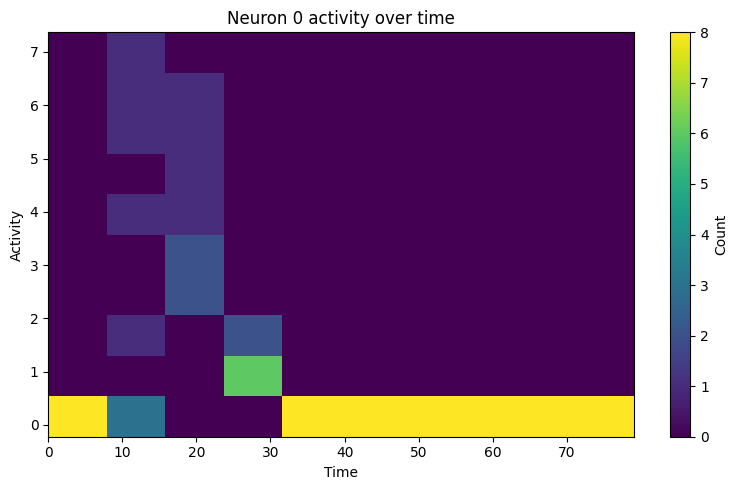

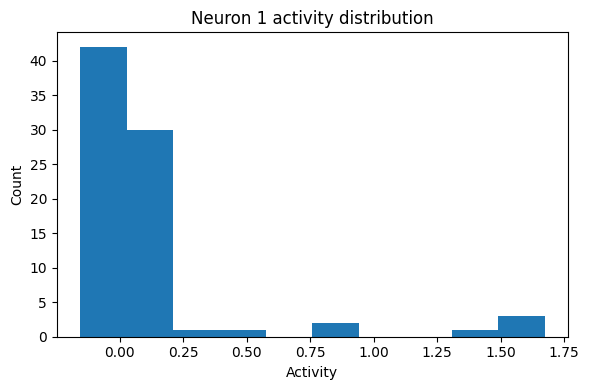

In [26]:
ill.plot_neural_activity_histogram(0)

ill.plot_neural_activity_histogram(1, two_dim=False)

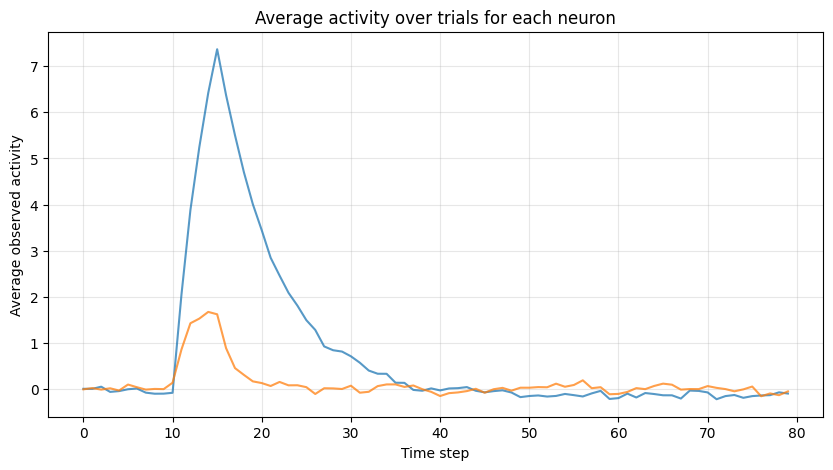

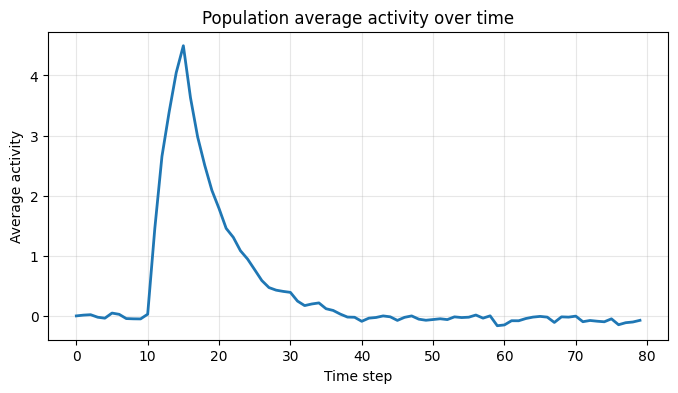

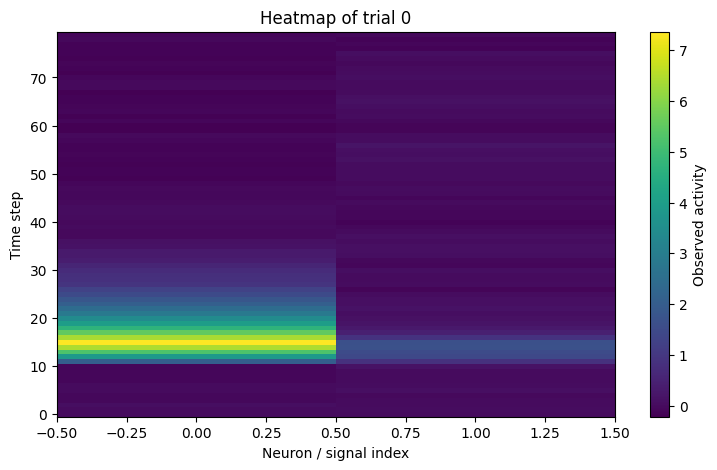

In [27]:
ill.plot_trial_average()

ill.plot_population_average()

ill.plot_heatmap()

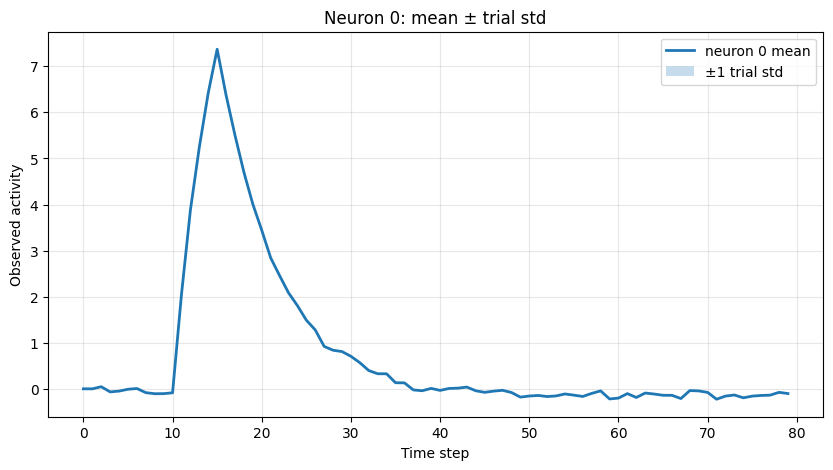

Mean trial std for neuron 0: 0.000000
Max trial std for neuron 0: 0.000000


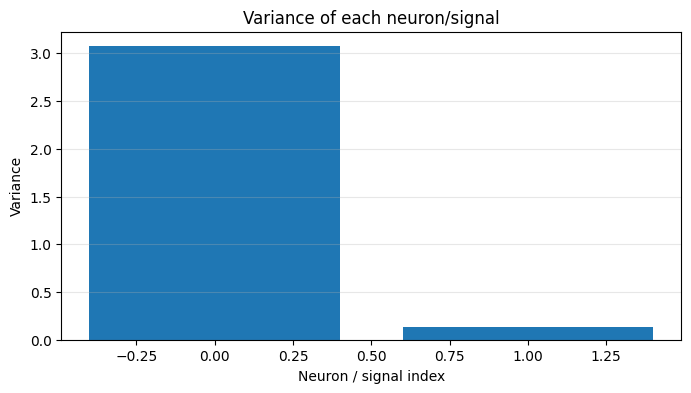

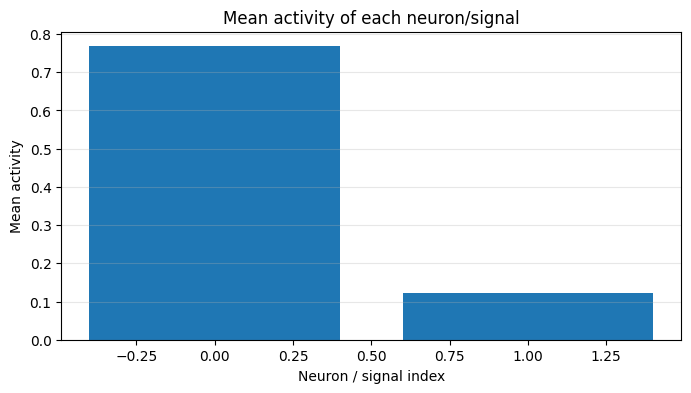

In [28]:
ill.plot_neuron_with_trial_std()

ill.plot_neuron_variance()

ill.plot_neuron_mean_activity()

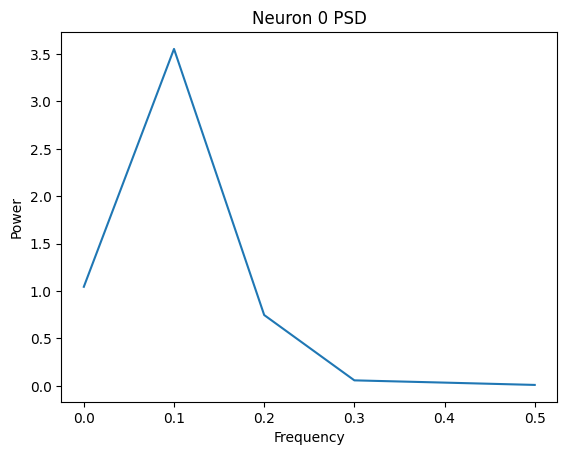

/home/arnav/Desktop/Projects/GG4/Illustrator_arnav.py:308: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 80, using nperseg = 80
  freqs, psd = welch(x, fs=fs, nperseg=nperseg)


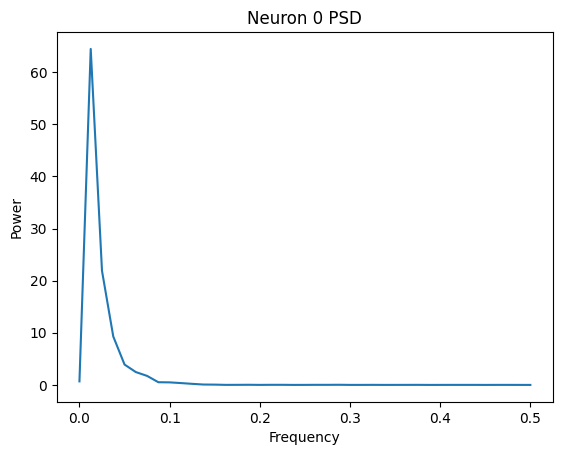

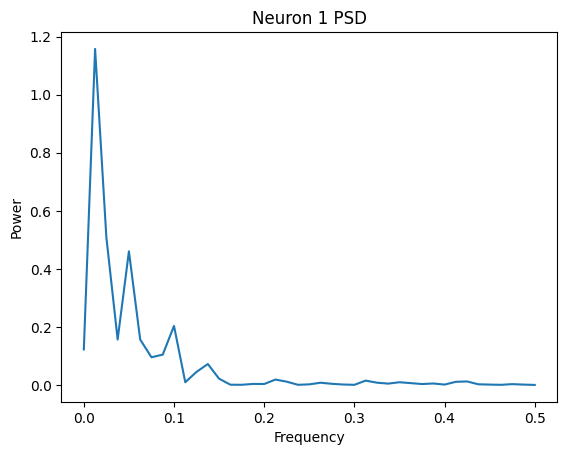

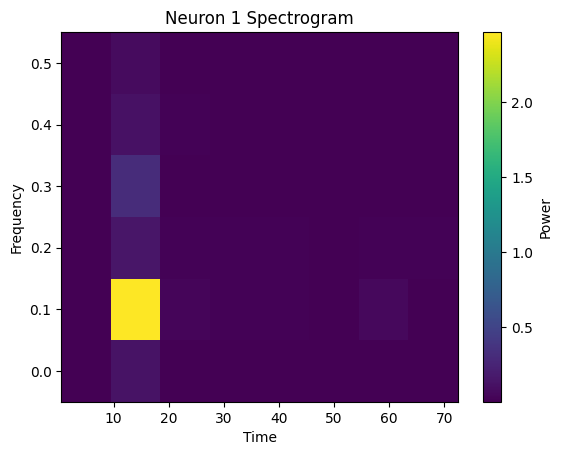

In [29]:
ill.plot_spectrum(0, spectrum='psd')

ill.plot_spectrum([0,1], spectrum='psd', nperseg=256)


ill.plot_spectrum(1, spectrum='spectrogram')

In [ ]:
corr = ill.get_correlation_matrix()
inter_neuron = ill.get_inter_neuron_covariance_matrix(0)
#time_1 = ill.get_time_covariance_matrix([0,1], [0,3])
trial = ill.get_trial_covariance_matrix()

#cov_compare = ill.compare_cov_matrices(time_1[0], time_1[1])
dissimlarity = ill.get_dissimilarity_matrix()

ill.plot_matrix(corr, 'Correlation')
ill.plot_matrix(inter_neuron, 'inter_neuron')
#ill.plot_matrix(time_1[0], 'temporal: 0')
ill.plot_matrix(trial)

IndexError: index 3 is out of bounds for axis 0 with size 1